Notebook for classical Bayesian Optimization on Tilt and Thickness<br>
Written by Dasol Yoon and Poompol Buathong<br>
Last edited on Dec 18, 2024

Installation note:<br>
- botorch=0.10.0
- conda install -c conda-forge pytorch botorch=0.10.0 jupyterlab ipympl

*TODO* Fixed the error message regarding tensor, by adding `, **kwargs:`. See if this version is compatible with windows or linux or other versions of python.

In [1]:
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

/opt/miniconda3/envs/BOttV02/bin/python
3.13.1 | packaged by conda-forge | (main, Dec  5 2024, 21:09:18) [Clang 18.1.8 ]
sys.version_info(major=3, minor=13, micro=1, releaselevel='final', serial=0)


In [2]:
%matplotlib inline

In [3]:
import torch
import random
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_model
from botorch.acquisition.objective import GenericMCObjective
from botorch.models.gp_regression import FixedNoiseGP, SingleTaskGP
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf

import math
import numpy as np
import matplotlib.pyplot as plt

# use a GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")
dtype = torch.double

Using device: mps


In [4]:
import scipy.ndimage
import glob
from datetime import datetime
import warnings

In [5]:
from botorch.sampling.normal import IIDNormalSampler
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.sampling import draw_sobol_samples

In [6]:
from botorch.models.transforms import Standardize
from botorch.models.transforms.input import Normalize
from mpl_toolkits.mplot3d import axes3d

### set up file path and load the diffraction pattern to be evaluated (`y_raw`) for the thickness and tilt (`x_real`)

In [7]:
#change the file path to where the dataset is/will be stored

#fpath = 'D:/Lab/Experiments/20231100-TiltML/data/data/1/simulation/'
fpath = '/Users/dash/Documents/Cornell/BOtt/simulation/'

In [8]:
def load(x):
    #----variables----
    #x: [[thickness [angstrom], tilt]]
    #returns pre-simulated PACBED image.
    thickness=x[0,0]
    tilt = x[0,1]    
    
    tag = '/{:04d}'.format(int(thickness))
    imgPath = glob.glob(fpath+'Tilt_{}_Azimuth_0_Conv_Angle_25.0/'.format(int(tilt))
                        +tag[:4]+'*.tif')[0] #get rid of one digit number #1st in list
    try: #load PACBED from the directory
        pacbed = plt.imread(imgPath)
        pacbed = pacbed[25:-25,25:-25].astype(np.float64) #added 20241112. bad simulation. crop zeroes.
    except: #handle exceptions
        print('no such file: ' +imgPath)

    pacbed_norm = (pacbed-np.min(pacbed))/(np.max(pacbed)-np.min(pacbed)) #normalize 0-1

    #Optional: print which file was loaded. unicode for angstrom
    #print('thickness: {} \u212B  || shape: {} || filename: '.format(x, pacbed_norm.shape)+imgPath[90:])
    
    return torch.Tensor(pacbed_norm.reshape(-1)) #change to tensor

In [9]:
# This is the correct value of the parameter
x_real = np.array([[250,4]])

# Get the PACBED at the thickness of x_real
y_raw = load(x_real)

# Upper and lower bounds for our search
lowerT = 10
upperT = 500

In [10]:
def pixelSSE(y_pred_raw): #torch
    err = y_pred_raw-y_raw #y_pred_raw: image I want to assess
    return np.power(err,2).sum().unsqueeze(-1)

In [11]:
def classicalObj(x): #negative sign for maximization
    return - pixelSSE(load(x))

In [12]:
def add_data(new_x, x=None, y=None, obj=None):
    if len(new_x.shape)==1: #if it's size([n])
        new_x = new_x.unsqueeze(0) #make it size([n,1])
    if x is None:
        x = torch.tensor([])
    if y is None:
        y = torch.tensor([])
    if obj is None:
        obj = torch.tensor([])
    new_y = load(new_x) # y is a tensor
    new_obj = - pixelSSE(new_y) # this is our objective

    # x and obj are both 2D tensors that are nx1
    # y is a 3D tensor that is nx20x20 -> 12
    x = torch.cat((x, new_x),dim=0)
    y = torch.cat((y, new_y.unsqueeze(0)),dim=0)
    obj = torch.cat((obj, torch.tensor(new_obj).unsqueeze(0)),dim=0)
    return x.to(torch.double), y.to(torch.double), obj.to(torch.double)

In [31]:
def plot_posterior_classic(ax,model,gridX1,gridX2,train_x,train_y,legend=True):
    with torch.no_grad():
        test_x = torch.stack([gridX1.flatten(),gridX2.flatten()],dim=1)
        # Calculate the posterior at the test points
        posterior = model.posterior(test_x)

        # Extract the mean and covariance (2D)
        mean = posterior.mean.cpu().numpy()  # Mean of posterior
        variance = posterior.mvn.covariance_matrix.cpu().numpy()  # Covariance matrix

        # For visualization, we'll calculate the 2D confidence region (2 std deviations)
        # Extracting the diagonal of the covariance matrix for 2D
        std_dev = np.sqrt(np.diagonal(variance))

        # Compute upper and lower bounds for both dimensions
        upper = mean + 2 * std_dev.reshape(-1,1)
        lower = mean - 2 * std_dev.reshape(-1,1)

        # Reshape the mean and bounds for plotting
        mean_reshaped = mean.reshape(gridX1.shape)
        upper_reshaped = upper.reshape(gridX1.shape)
        lower_reshaped = lower.reshape(gridX1.shape)

        # Plot training points as black stars
        ax.plot(train_x[:, 0].cpu().numpy(), 
                train_x[:, 1].cpu().numpy(), 
                train_y[:,0].cpu().numpy(),'k*')
        
        # Plot posterior means as a surface 
        post = ax.plot_surface(gridX1, gridX2, mean_reshaped, cmap='autumn_r', alpha=0.5)

        # Upper and lower bounds
        ax.plot_wireframe(gridX1,gridX2,upper_reshaped,alpha=0.5) #lw=0.5, rstride=2, cstride=2,
        ax.plot_wireframe(gridX1,gridX2,lower_reshaped,alpha=0.5)
        
        # Add color bar to indicate posterior mean value
        plt.colorbar(post)

        ax.set_xlabel('thickness');ax.set_ylabel('tilt')
        
    if legend:
        ax.legend(['Observed Data', 'Mean', 'Confidence'],
                  bbox_to_anchor=[0.5,1],loc='lower center')

In [14]:
def generate_initial_data(n_initial_points):    
    new_x = (
            draw_sobol_samples(
                bounds=torch.tensor([[lowerT,1], [upperT,10]]).to(torch.double),
                n=n_initial_points,
                q=1,
            )
        )
    for i in range(n_initial_points):
        if i == 0:
            x,y,obj = add_data(new_x[i,...])
        else:
            x,y,obj = add_data(new_x[i,...],x,y,obj)
    return x,y,obj

In [15]:
def plotEI(ax,gridX1,gridX2, ei, new_pt):
    test_x = torch.stack([gridX1.flatten(),gridX2.flatten()],dim=1)
    acq = ei.forward(test_x.unsqueeze(1))
    acqValues = acq.detach().numpy().reshape(gridX1.shape)

    # Contour plot of EI over the 2D input space
    ct = ax.contourf(gridX1.numpy(), gridX2.numpy(), 
                     acqValues, cmap='viridis')
    plt.colorbar(ct)
    
    # Mark the new point found by the optimizer
    ax.plot(new_pt[0,0].numpy(), new_pt[0,1].numpy(), 'ro')
    
    ax.set_title('Expected Improvement (EI)')
    ax.set_xlabel('Thickness'); ax.set_ylabel('Tilt');

/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_6279/2853452939.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.power(err,2).sum().unsqueeze(-1)
/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_6279/3904316988.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obj = torch.cat((obj, torch.tensor(new_obj).unsqueeze(0)),dim=0)


torch.Size([4, 2]) torch.Size([4, 22500]) torch.Size([4, 1])
Best value found: -44.025482177734375


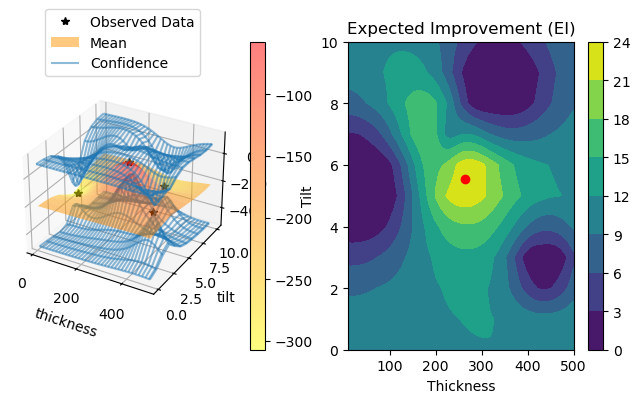

Iteration 0, measuring at x=263.7265319824219,5.535923480987549
Best obj found so far: -12.986251831054688 from interation # 4 at x of 263.7, 5.5


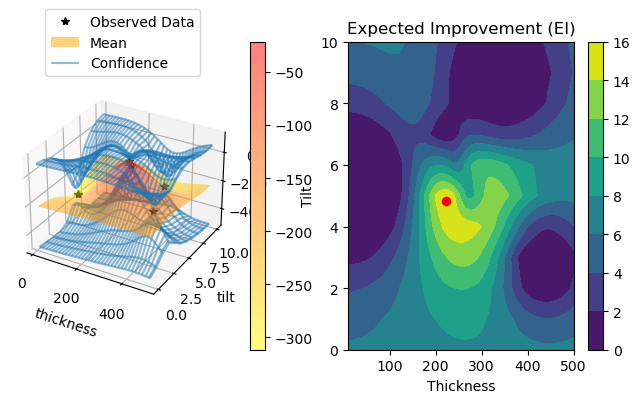

Iteration 1, measuring at x=223.22372436523438,4.844000339508057
Best obj found so far: -6.644861698150635 from interation # 5 at x of 223.2, 4.8


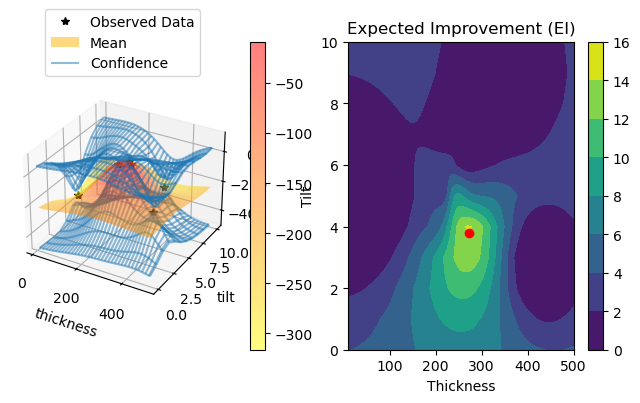

Iteration 2, measuring at x=271.5825500488281,3.778316020965576
Best obj found so far: -6.644861698150635 from interation # 5 at x of 223.2, 4.8


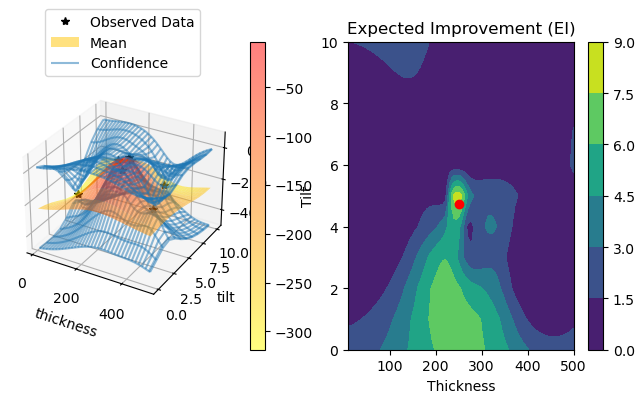

Iteration 3, measuring at x=250.55137634277344,4.728507041931152
Best obj found so far: -0.0 from interation # 7 at x of 250.6, 4.7


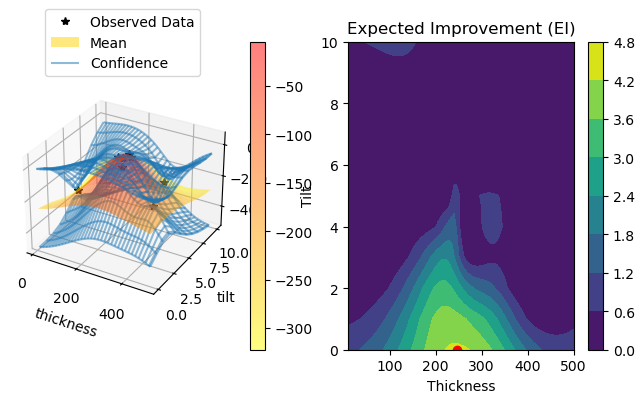

Iteration 4, measuring at x=246.66954040527344,0.0
Best obj found so far: -0.0 from interation # 7 at x of 250.6, 4.7
Time elapsed (hh:mm:ss.ms):  0:00:03.282240 


In [32]:
#smaller number of BO points to see EI and and posterior plots
start = datetime.now()
seed = 111
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

n_initial_points = 4
n_BO_points = 5

x,y,obj = generate_initial_data(n_initial_points=n_initial_points)
print(x.shape, y.shape, obj.shape)
        
best = [obj.max().detach().item()] #[obj.min()] # Store the index of the best value
best_x_idx = obj.argmax()
print('Best value found: {}'.format(best[-1]))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(n_BO_points):
        # Fit the model
        noise = torch.ones_like(obj) * 0.0001
        model = FixedNoiseGP(x, obj, noise, outcome_transform=Standardize(m=1),input_transform=Normalize(d=2))
        #TODO: question 1203: single task GP vs. fixed noise GP
        #NOTE: Standardization and normalization MUST be done! 
        #model = SingleTaskGP(x, obj ,outcome_transform=Standardize(m=1),input_transform=Normalize(d=2))
        fit_gpytorch_model(ExactMarginalLogLikelihood(model.likelihood, model))
    
        #print(model.train_targets.shape)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        mll(model(x), obj.squeeze(1)).item()
        
        # Optimize EI, considering the problem to be a minimization problem
        EI = ExpectedImprovement(model=model, best_f=obj.max())
        new_point, new_point_EI = optimize_acqf( #error: "_sobol_engine_draw" not implemented for 'Long'
            acq_function=EI,
            bounds=torch.tensor([[lowerT,0], [upperT,10]]).float(),#, #bounds is longtensor wihtout float()
            q=1,
            num_restarts=50,
            raw_samples=100,
        )
        
        # Plot the posterior and the EI
        f, (ax1,ax2) = plt.subplots(1, 2, figsize=(8, 4))
        gridx1,gridx2 = torch.meshgrid(torch.linspace(lowerT,upperT,101),torch.linspace(0,10,11))
        
        # Plot the posterior
        ax1.axis('off')
        ax1 = plt.subplot(121, projection='3d') #row, col, index
        plot_posterior_classic(ax1,model,gridx1,gridx2,x,obj)
        
        # Plot EI
        plotEI(ax2,gridx1,gridx2,EI,new_point)
        plt.show()
        print('Iteration {}, measuring at x={},{}'.format(i,new_point[0,0].item(),new_point[0,1].item()) )
        
        x,y,obj = add_data(new_point,x,y,obj) #new_point: [1,1] tensor
        best.append(obj.max().item()) #obj.min())
        best_x_idx=obj.argmax()
        print('Best obj found so far: {} from interation # {} at x of {:.1f}, {:.1f}'.format(obj.max(),best_x_idx,
                                                                                    x[best_x_idx,0].item(),
                                                                                   x[best_x_idx,1].item()))
    end = datetime.now()
    print('Time elapsed (hh:mm:ss.ms):  {} '.format(end-start))

In [35]:
plt.close('all')
%matplotlib inline

In [33]:
%matplotlib widget

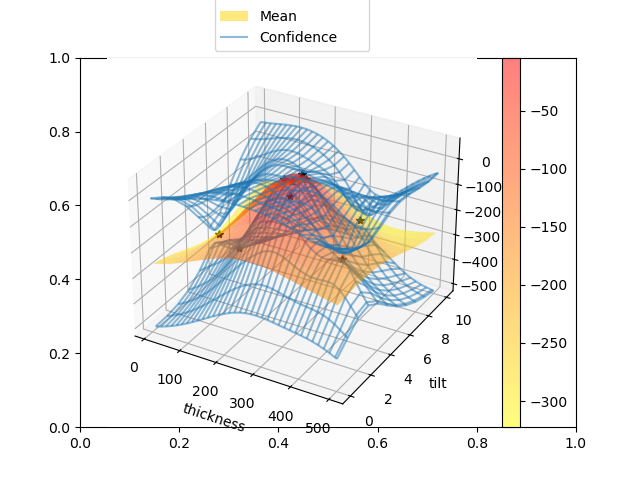

In [34]:
fig,ax = plt.subplots()
ax = plt.subplot(111, projection='3d') #row, col, index
plot_posterior_classic(ax,model,gridx1,gridx2,x,obj)

/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_6279/2853452939.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.power(err,2).sum().unsqueeze(-1)
/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_6279/3904316988.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obj = torch.cat((obj, torch.tensor(new_obj).unsqueeze(0)),dim=0)


torch.Size([4, 2]) torch.Size([4, 22500]) torch.Size([4, 1])
Best value found: -44.025482177734375


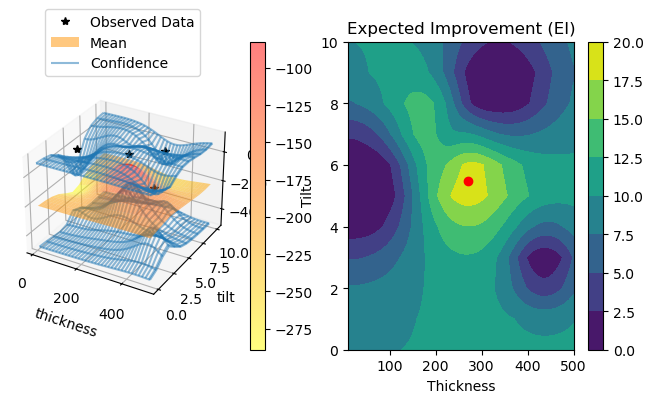

Iteration 0, measuring at x=271.10162353515625,5.472076416015625
Best obj found so far: -15.890198707580566 from interation # 4 at x of 271.1, 5.5


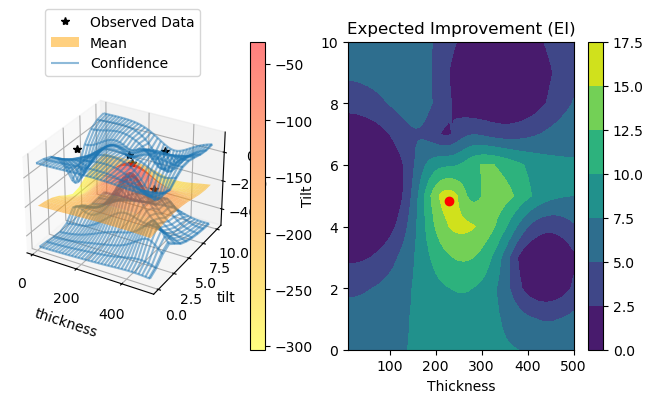

Iteration 1, measuring at x=229.98965454101562,4.824545860290527
Best obj found so far: -6.644861698150635 from interation # 5 at x of 230.0, 4.8


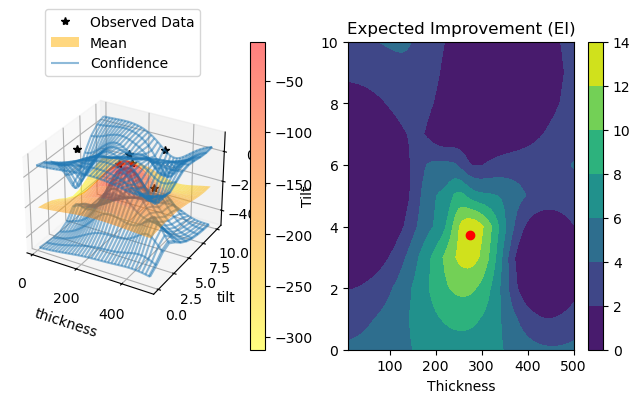

Iteration 2, measuring at x=275.2986145019531,3.73830246925354
Best obj found so far: -6.644861698150635 from interation # 5 at x of 230.0, 4.8


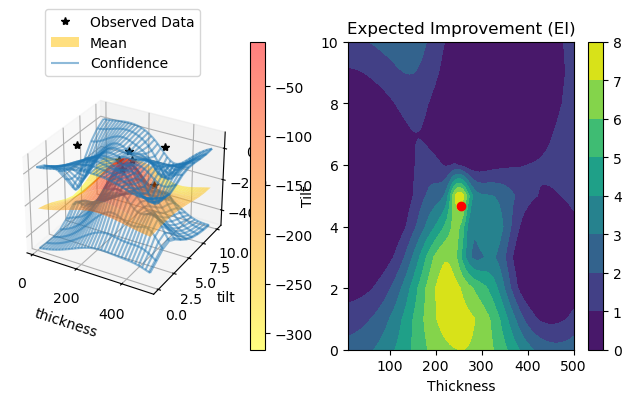

Iteration 3, measuring at x=255.62757873535156,4.665014266967773
Best obj found so far: -0.0 from interation # 7 at x of 255.6, 4.7


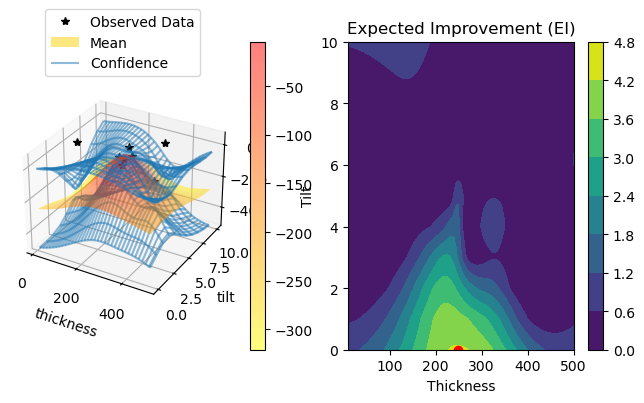

Iteration 4, measuring at x=249.71099853515625,0.0
Best obj found so far: -0.0 from interation # 7 at x of 255.6, 4.7
Time elapsed (hh:mm:ss.ms):  0:00:03.296698 


In [16]:
#archive version with SingleTaskGP
#smaller number of BO points to see EI and and posterior plots
start = datetime.now()
seed = 111
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

n_initial_points = 4
n_BO_points = 5

x,y,obj = generate_initial_data(n_initial_points=n_initial_points)
print(x.shape, y.shape, obj.shape)
        
best = [obj.max().detach().item()] #[obj.min()] # Store the index of the best value
best_x_idx = obj.argmax()
print('Best value found: {}'.format(best[-1]))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(n_BO_points):
        # Fit the model
        # noise = torch.ones_like(obj) * 0.0001
        # model = FixedNoiseGP(x, obj, noise)
        #TODO: question 1203: single task GP vs. fixed noise GP
        #NOTE: Standardization and normalization MUST be done! 
        model = SingleTaskGP(x, obj ,outcome_transform=Standardize(m=1),input_transform=Normalize(d=2))
        fit_gpytorch_model(ExactMarginalLogLikelihood(model.likelihood, model))
    
        #print(model.train_targets.shape)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        mll(model(x), obj.squeeze(1)).item()
        
        # Optimize EI, considering the problem to be a minimization problem
        EI = ExpectedImprovement(model=model, best_f=obj.max())
        new_point, new_point_EI = optimize_acqf( #error: "_sobol_engine_draw" not implemented for 'Long'
            acq_function=EI,
            bounds=torch.tensor([[lowerT,0], [upperT,10]]).float(),#, #bounds is longtensor wihtout float()
            q=1,
            num_restarts=50,
            raw_samples=100,
        )
        
        # Plot the posterior and the EI
        f, (ax1,ax2) = plt.subplots(1, 2, figsize=(8, 4))
        gridx1,gridx2 = torch.meshgrid(torch.linspace(lowerT,upperT,101),torch.linspace(0,10,11))
        
        # Plot the posterior
        ax1.axis('off')
        ax1 = plt.subplot(121, projection='3d') #row, col, index
        plot_posterior_classic(ax1,model,gridx1,gridx2,x,obj)
        
        # Plot EI
        plotEI(ax2,gridx1,gridx2,EI,new_point)
        plt.show()
        print('Iteration {}, measuring at x={},{}'.format(i,new_point[0,0].item(),new_point[0,1].item()) )
        
        x,y,obj = add_data(new_point,x,y,obj) #new_point: [1,1] tensor
        best.append(obj.max().item()) #obj.min())
        best_x_idx=obj.argmax()
        print('Best obj found so far: {} from interation # {} at x of {:.1f}, {:.1f}'.format(obj.max(),best_x_idx,
                                                                                    x[best_x_idx,0].item(),
                                                                                   x[best_x_idx,1].item()))
    end = datetime.now()
    print('Time elapsed (hh:mm:ss.ms):  {} '.format(end-start))

### Run the code with different seeds
TODO: need to copy and paste the 2 variable version for the following part

Seed 0: Best obj -2.619086742401123 from interation # 23 at x of 343.5732727050781


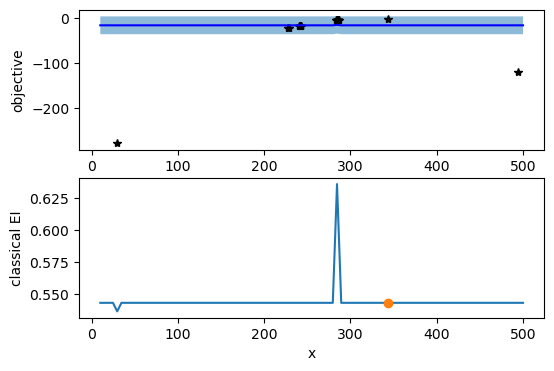

Time elapsed (hh:mm:ss.ms):  0:00:04.300709 

Seed 1: Best obj -1.6265268325805664 from interation # 7 at x of 300.6782531738281


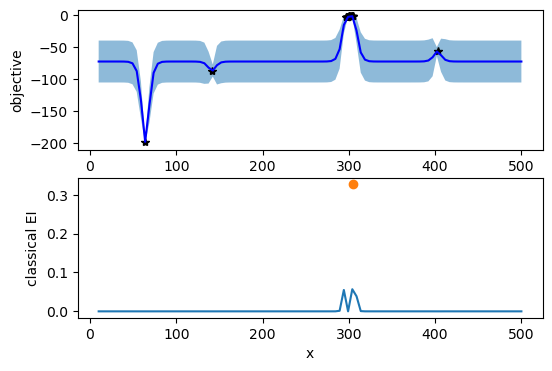

Time elapsed (hh:mm:ss.ms):  0:00:04.360218 

Seed 2: Best obj -1.6265268325805664 from interation # 3 at x of 305.9051516652107


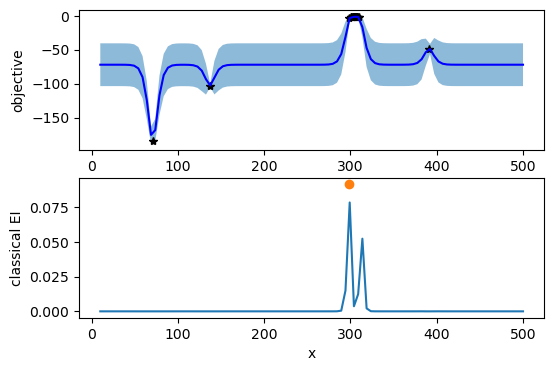

Time elapsed (hh:mm:ss.ms):  0:00:04.587820 

Seed 3: Best obj -1.6265268325805664 from interation # 11 at x of 300.2608642578125


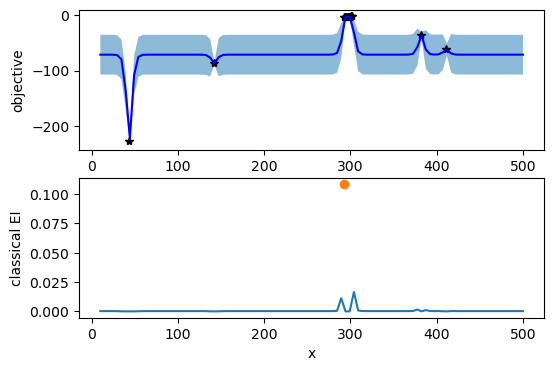

Time elapsed (hh:mm:ss.ms):  0:00:04.219584 

Seed 4: Best obj -13.5692138671875 from interation # 20 at x of 369.5134582519531


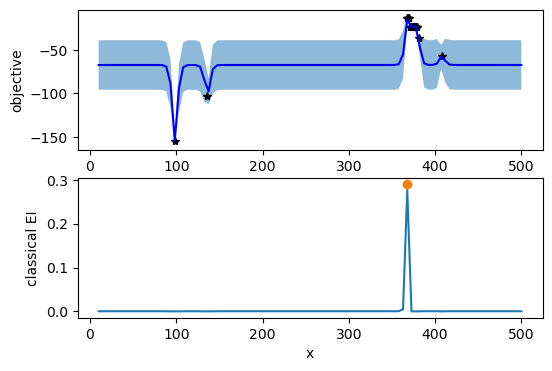

Time elapsed (hh:mm:ss.ms):  0:00:05.109317 

Seed 5: Best obj -17.933347702026367 from interation # 0 at x of 245.34236073493958


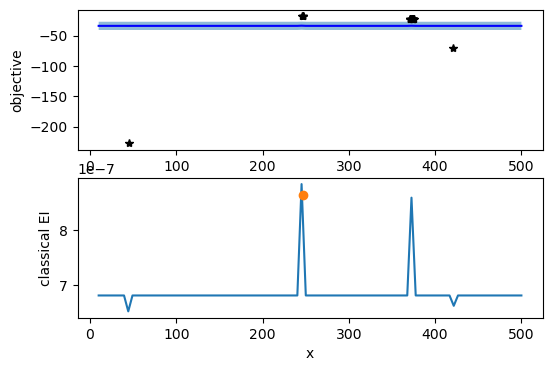

Time elapsed (hh:mm:ss.ms):  0:00:03.652445 

Seed 6: Best obj -2.619086742401123 from interation # 0 at x of 347.9362976551056


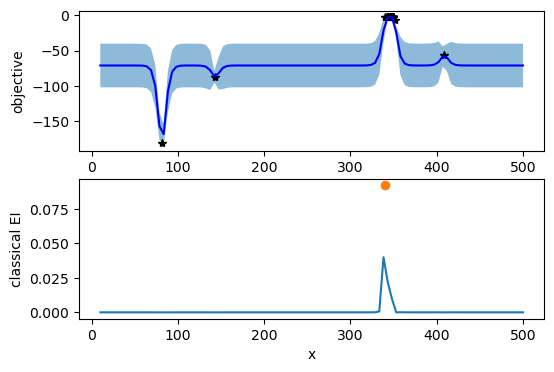

Time elapsed (hh:mm:ss.ms):  0:00:04.643969 

Seed 7: Best obj -2.662409782409668 from interation # 1 at x of 292.5159616023302


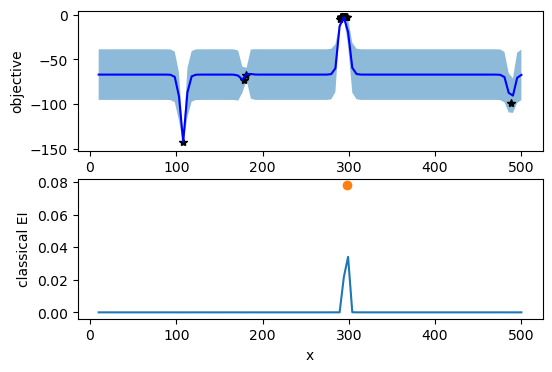

Time elapsed (hh:mm:ss.ms):  0:00:04.374516 

Seed 8: Best obj -4.797336578369141 from interation # 21 at x of 280.5509948730469


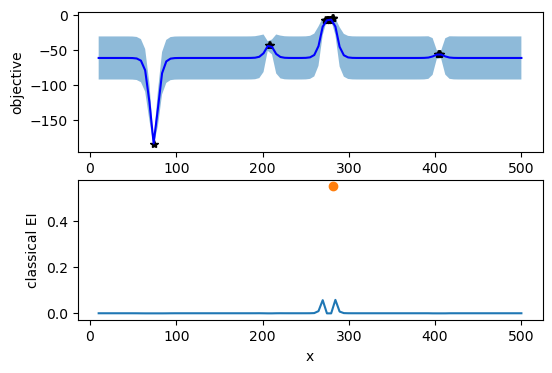

Time elapsed (hh:mm:ss.ms):  0:00:06.577825 

Seed 9: Best obj -7.596424102783203 from interation # 0 at x of 271.2269192934036


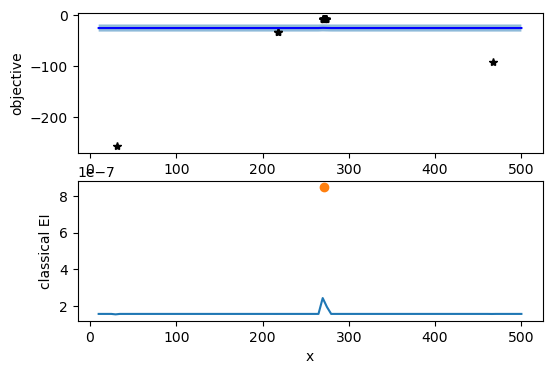

Time elapsed (hh:mm:ss.ms):  0:00:04.187286 

Seed 10: Best obj -0.5697631239891052 from interation # 4 at x of 312.3406982421875


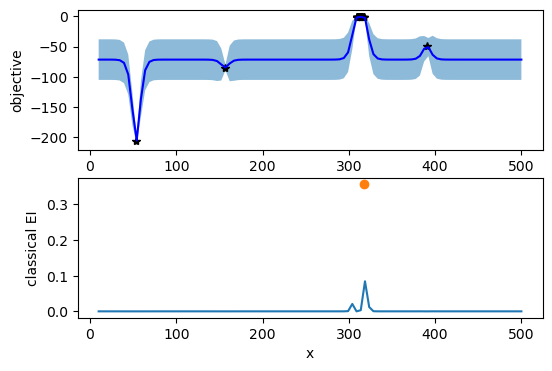

Time elapsed (hh:mm:ss.ms):  0:00:04.400253 

Seed 11: Best obj -13.5692138671875 from interation # 0 at x of 366.33192896842957


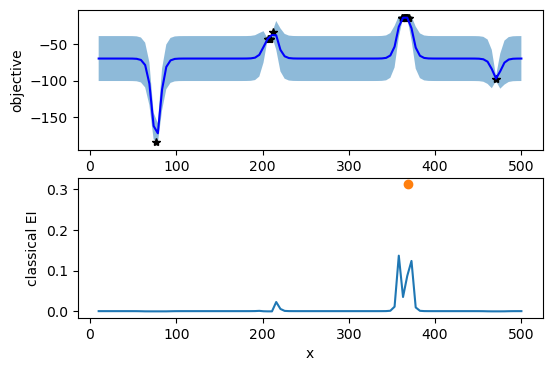

Time elapsed (hh:mm:ss.ms):  0:00:05.658716 

Seed 12: Best obj -2.662409782409668 from interation # 5 at x of 290.2398681640625


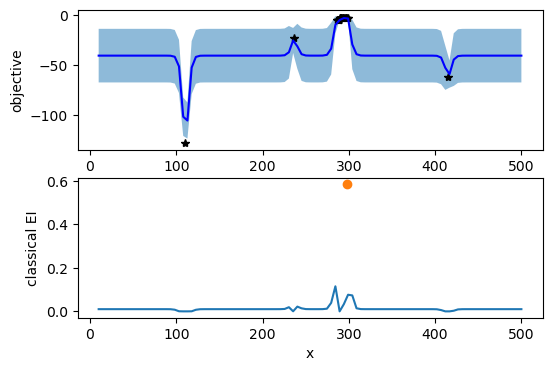

Time elapsed (hh:mm:ss.ms):  0:00:06.454800 

Seed 13: Best obj -11.600391387939453 from interation # 2 at x of 268.3210750948638


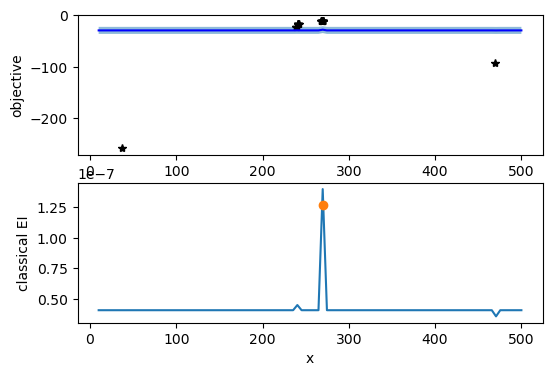

Time elapsed (hh:mm:ss.ms):  0:00:04.001393 

Seed 14: Best obj -4.797336578369141 from interation # 14 at x of 280.3038330078125


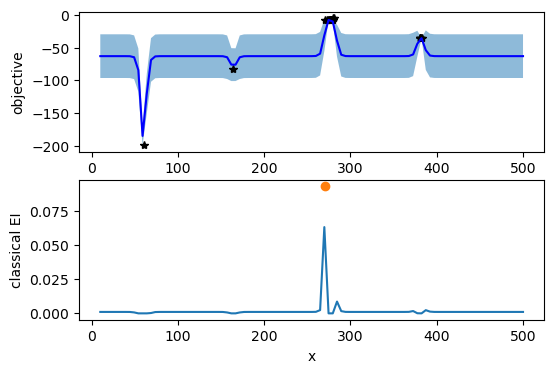

Time elapsed (hh:mm:ss.ms):  0:00:04.126104 

Seed 15: Best obj -2.619086742401123 from interation # 4 at x of 349.8086242675781


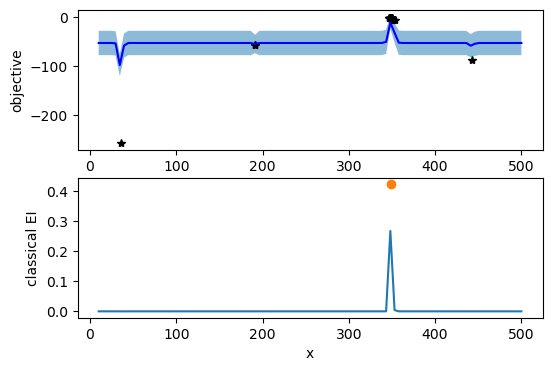

Time elapsed (hh:mm:ss.ms):  0:00:03.940452 

Seed 16: Best obj -2.619086742401123 from interation # 0 at x of 348.3112186193466


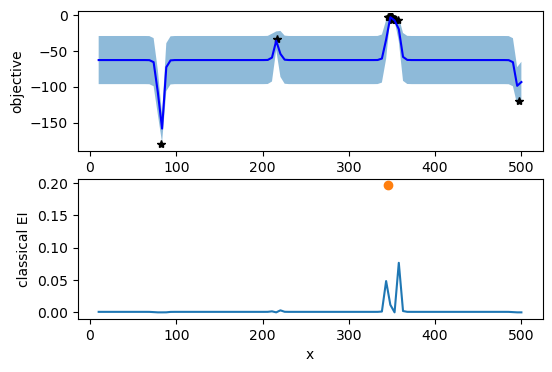

Time elapsed (hh:mm:ss.ms):  0:00:04.039443 

Seed 17: Best obj -0.7697936296463013 from interation # 17 at x of 339.9036865234375


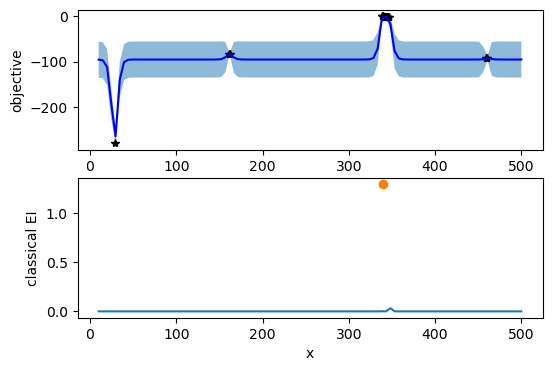

Time elapsed (hh:mm:ss.ms):  0:00:03.943444 

Seed 18: Best obj -1.6265268325805664 from interation # 3 at x of 301.6847945936024


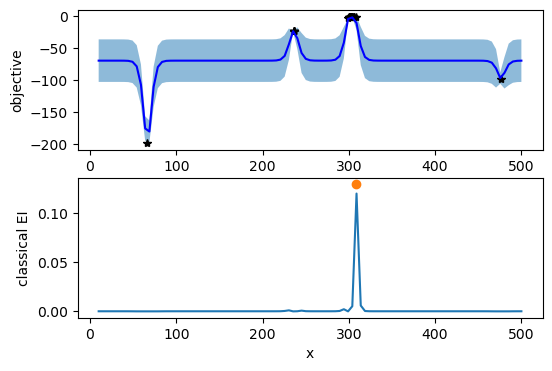

Time elapsed (hh:mm:ss.ms):  0:00:06.360700 

Seed 19: Best obj -23.094207763671875 from interation # 0 at x of 375.35804092884064


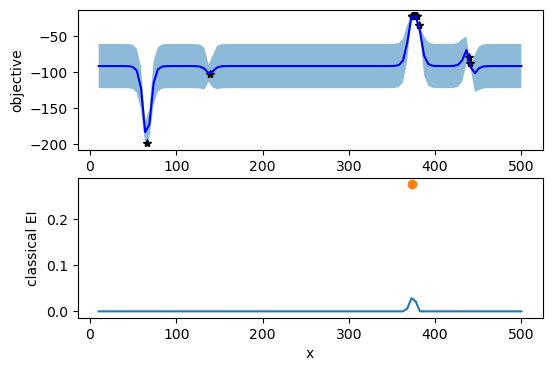

Time elapsed (hh:mm:ss.ms):  0:00:04.303356 

Seed 20: Best obj -2.619086742401123 from interation # 21 at x of 349.96636962890625


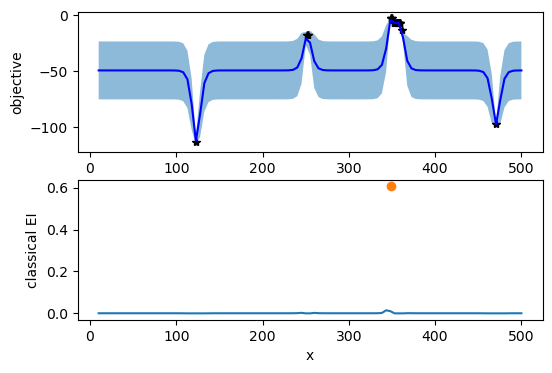

Time elapsed (hh:mm:ss.ms):  0:00:09.984442 

Seed 21: Best obj -7.596424102783203 from interation # 22 at x of 270.2554016113281


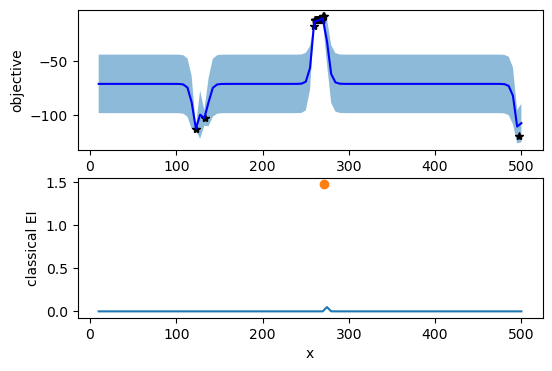

Time elapsed (hh:mm:ss.ms):  0:00:04.427964 

Seed 22: Best obj -2.662409782409668 from interation # 9 at x of 290.2331848144531


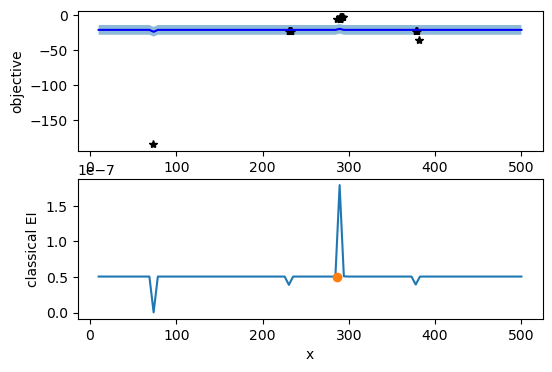

Time elapsed (hh:mm:ss.ms):  0:00:03.432978 

Seed 23: Best obj -6.970828533172607 from interation # 2 at x of 359.2091767769307


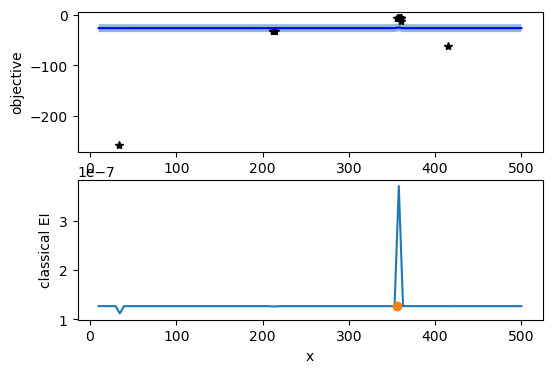

Time elapsed (hh:mm:ss.ms):  0:00:03.709923 

Seed 24: Best obj -11.600391387939453 from interation # 2 at x of 260.4635874647647


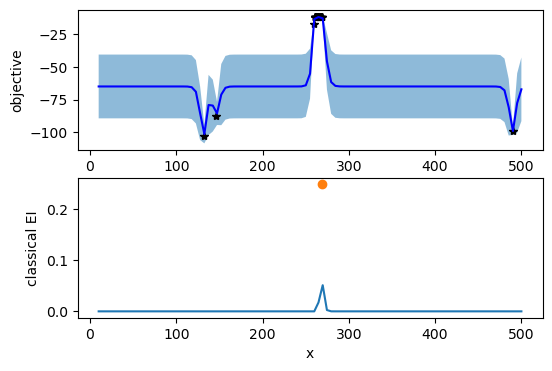

Time elapsed (hh:mm:ss.ms):  0:00:04.582602 

Seed 25: Best obj -2.662409782409668 from interation # 2 at x of 292.19626422971487


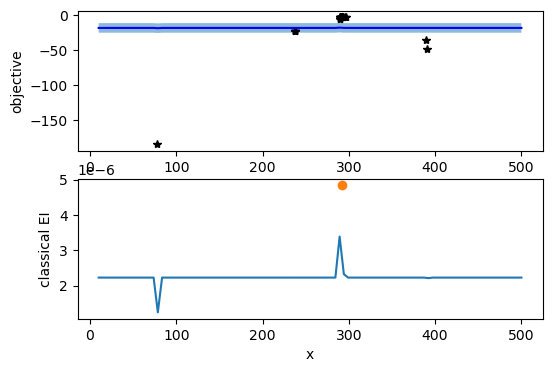

Time elapsed (hh:mm:ss.ms):  0:00:03.492170 

Seed 26: Best obj -2.619086742401123 from interation # 20 at x of 348.69952392578125


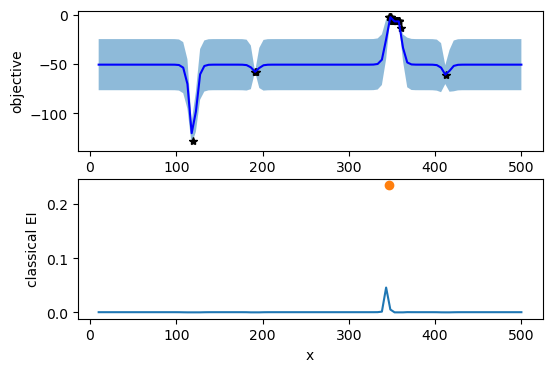

Time elapsed (hh:mm:ss.ms):  0:00:05.583098 

Seed 27: Best obj -0.5697631239891052 from interation # 0 at x of 314.476974606514


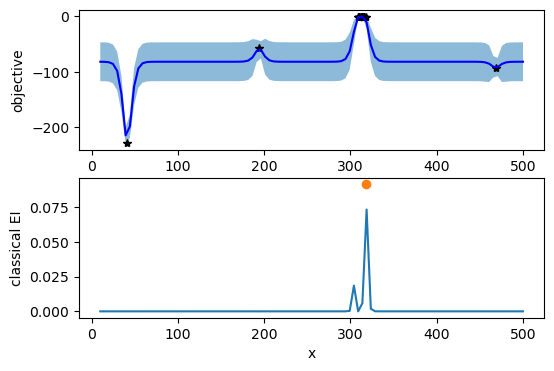

Time elapsed (hh:mm:ss.ms):  0:00:03.797717 

Seed 28: Best obj -2.662409782409668 from interation # 0 at x of 291.61541163921356


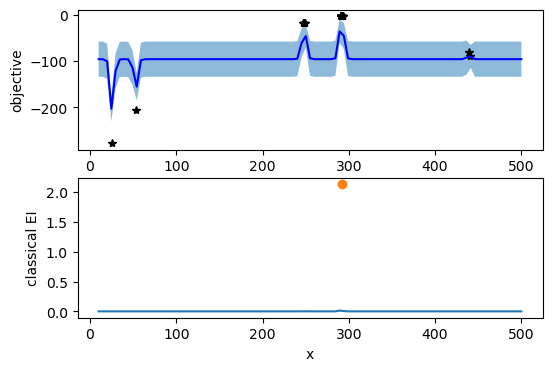

Time elapsed (hh:mm:ss.ms):  0:00:03.844504 

Seed 29: Best obj -6.970828533172607 from interation # 17 at x of 358.8192138671875


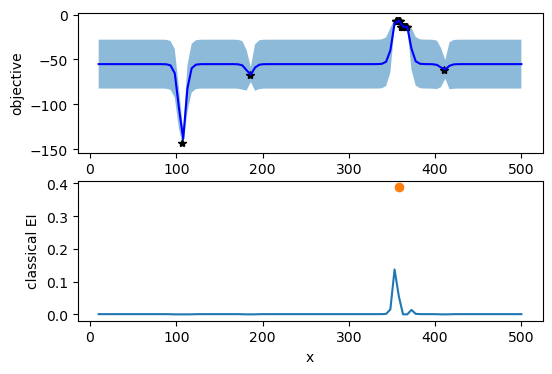

Time elapsed (hh:mm:ss.ms):  0:00:05.665163 



In [127]:
##Need to modify to take 2 variables
bestArr = []
xArr = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for seed in range(30):
        start = datetime.now()
    
        np.random.seed(seed)
        torch.manual_seed(seed)
        random.seed(seed)
        
        n_initial_points = 4
        n_BO_points = 20
        
        # # Generate initial data: several datapoints at random
        # # Each one of them will be uniform between 0 and 3
        # for i in range(n_initial_points):    
        #     new_x = torch.tensor(lower + np.random.rand(1)*(upper-lower)).unsqueeze(0) # This is a vector containing 1 entry
        #     if i == 0:
        #         x,y,obj = add_data(new_x)
        #     else:
        #         x,y,obj = add_data(new_x,x,y,obj)
        x,y,obj = generate_initial_data(n_initial_points=n_initial_points)
        
        #print(x.shape, y.shape, obj.shape)
                
        best = [obj.max().detach().item()] #[obj.min()] # Store the index of the best value
        best_x_idx = obj.argmax()
        #print('Best value found: {}'.format(best[-1]))
        
        for i in range(n_BO_points):
            # Fit the model
            # noise = torch.ones_like(obj) * 0.0001
            # model = FixedNoiseGP(x, obj, noise)
            #question 1203: single task GP vs. fixed noise GP
            model = SingleTaskGP(x, obj)
            fit_gpytorch_model(ExactMarginalLogLikelihood(model.likelihood, model))
        
            #print(model.train_targets.shape)
            mll = ExactMarginalLogLikelihood(model.likelihood, model)
            mll(model(x), obj.squeeze(1)).item()
            
            # Optimize EI, considering the problem to be a minimization problem
            EI = ExpectedImprovement(model=model, best_f=obj.max())
            new_point, new_point_EI = optimize_acqf( #error: "_sobol_engine_draw" not implemented for 'Long'
                acq_function=EI,
                bounds=torch.tensor([[lower], [upper]]).float(),#, #bounds is longtensor wihtout float()
                q=1,
                num_restarts=50,
                raw_samples=100,
            )
            
            # # Plot the posterior and the EI
            # f, (ax1,ax2) = plt.subplots(2, 1, figsize=(6, 4))
            # test_x = torch.linspace(lower, upper, 101)
            
            # # Plot the posterior
            # plot_posterior_classic(ax1,model,test_x,x,obj,legend=False)
            
            # # Plot EI
            # acq = EI.forward(test_x.unsqueeze(1).unsqueeze(1))
            # ax2.plot(test_x.numpy(), acq.detach().numpy(), '-', new_point.numpy(), new_point_EI.numpy(),'o')
            # ax2.set_ylabel('classical EI')
            # ax2.set_xlabel('x')
            
            #print('Iteration {}, measuring at x={}'.format(i,new_point.item()) )
            #plt.show()
            
            x,y,obj = add_data(new_point,x,y,obj) #new_point: [1,1] tensor
            best.append(obj.max().item()) #obj.min())
            best_x_idx=obj.argmax()
            #print('Best obj found so far: {} from interation # {} at x of {}'.format(obj.max(),best_x_idx,x[best_x_idx].item()))
        
        print('Seed {}: Best obj {} from interation # {} at x of {}'.format(seed,
                                                                            obj.max(),
                                                                            best_x_idx,
                                                                            x[best_x_idx].item()))
        # Plot the posterior and the EI
        f, (ax1,ax2) = plt.subplots(2, 1, figsize=(6, 4))
        test_x = torch.linspace(lower, upper, 101)
        
        # Plot the posterior
        plot_posterior_classic(ax1,model,test_x,x,obj,legend=False)
        
        # Plot EI
        acq = EI.forward(test_x.unsqueeze(1).unsqueeze(1))
        ax2.plot(test_x.numpy(), acq.detach().numpy(), '-', new_point.numpy(), new_point_EI.numpy(),'o')
        ax2.set_ylabel('classical EI')
        ax2.set_xlabel('x')
        plt.show()
    
        torch.cuda.synchronize()
        end = datetime.now()
        print('Time elapsed (hh:mm:ss.ms):  {} \n'.format(end-start))
    
        bestArr.append(best)
        xArr.append(x.squeeze().numpy())

In [128]:
bestArr = np.array(bestArr)
xArr = np.array(xArr)
np.savez('20241202-classical_initial4_sobol.npz',bestArr=bestArr,xArr = xArr)

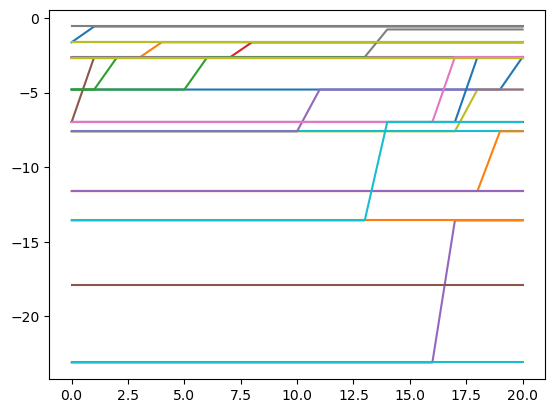

In [129]:
plt.figure()
plt.plot(bestArr.T);

In [130]:
bestAvg = np.mean(bestArr,axis=0)
bestStd = np.std(bestArr,axis=0)

Text(0, 0.5, 'Objective')

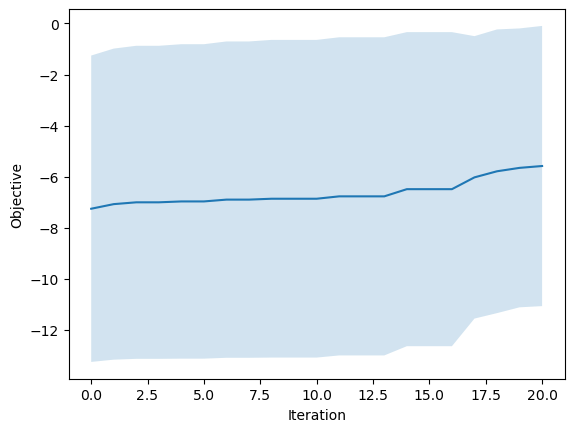

In [131]:
plt.figure()
plt.plot(bestAvg)
plt.fill_between(range(len(bestAvg)),bestAvg-bestStd,bestAvg+bestStd,alpha=0.2)
plt.xlabel('Iteration')
plt.ylabel('Objective')

In [133]:
xArr[:,:4]

array([[242.80252457, 284.46034088, 494.01378768,  29.34979807],
       [141.18547916, 402.80627703, 297.09180743,  64.1667283 ],
       [391.01745307, 137.01520036,  70.86421293, 305.90515167],
       [ 43.54791299, 298.61443738, 381.90429728, 142.09033797],
       [408.23554575,  98.44437287, 135.91433915, 377.40499837],
       [245.34236073, 373.88738263, 420.49991908,  45.64647655],
       [347.93629766, 143.39577225,  81.50254738, 408.89908633],
       [107.74183258, 292.5159616 , 488.00640354, 180.7322476 ],
       [277.81483293,  74.06961176, 207.47851679, 403.8058171 ],
       [271.22691929,  31.21877475, 217.54335041, 467.47561959],
       [156.44393295, 309.71046337, 390.26918144,  53.52155822],
       [366.33192897, 209.1712231 ,  76.5719749 , 471.07256231],
       [110.57530135, 288.84702358, 415.11853131, 236.83188421],
       [241.30301595, 469.73667501, 268.32107509,  37.02054624],
       [380.06177008, 164.36091057,  60.15010052, 277.49398693],
       [190.99755675, 350

## archive

Seed 0: Best obj -0.0 from interation # 20 at x of 320.7794494628906


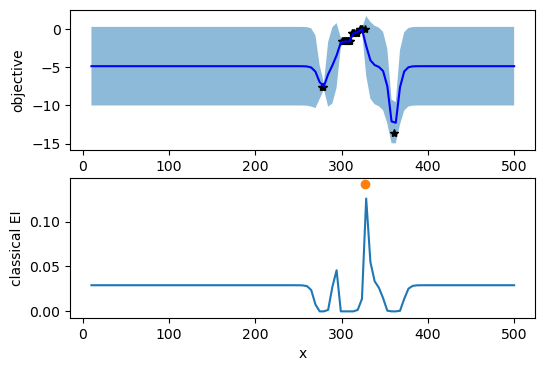

Time elapsed (hh:mm:ss.ms):  0:00:05.541080 

Seed 1: Best obj -13.5692138671875 from interation # 1 at x of 362.9590017866575


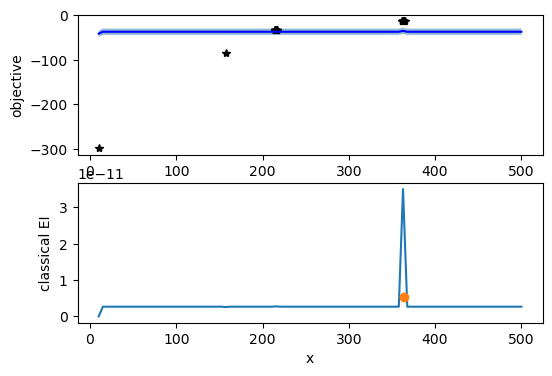

Time elapsed (hh:mm:ss.ms):  0:00:04.129121 

Seed 2: Best obj -4.797336578369141 from interation # 4 at x of 281.7010192871094


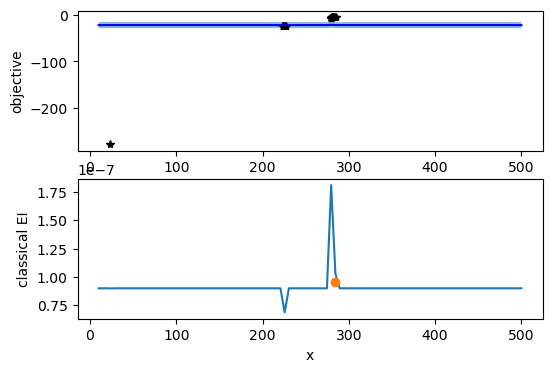

Time elapsed (hh:mm:ss.ms):  0:00:03.873689 

Seed 3: Best obj -2.619086742401123 from interation # 22 at x of 349.65228271484375


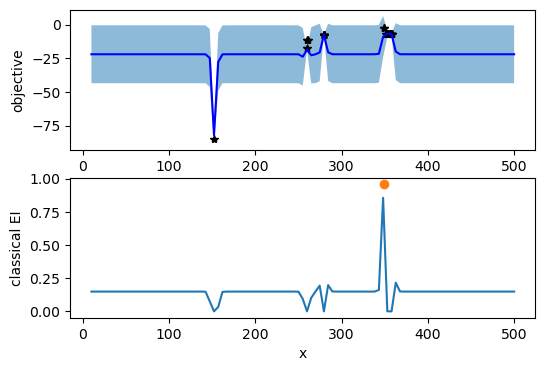

Time elapsed (hh:mm:ss.ms):  0:00:04.789074 

Seed 4: Best obj -4.797336578369141 from interation # 15 at x of 280.3632507324219


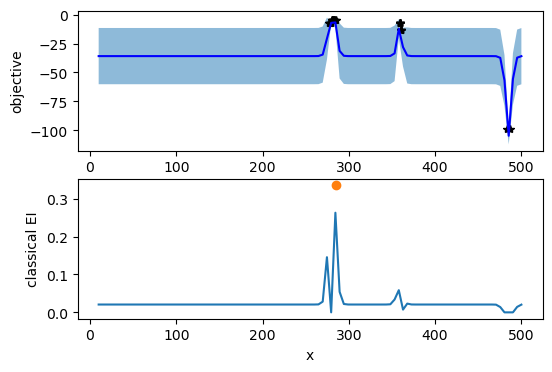

Time elapsed (hh:mm:ss.ms):  0:00:07.078519 

Seed 5: Best obj -70.80307006835938 from interation # 20 at x of 428.7987365722656


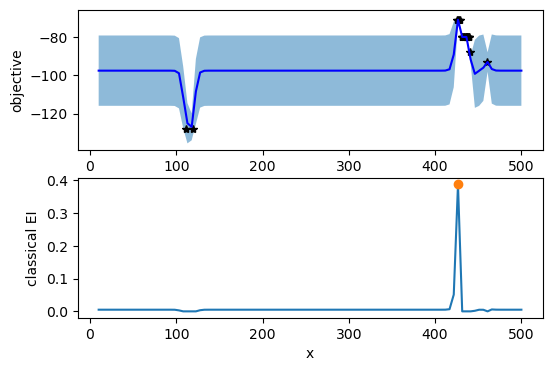

Time elapsed (hh:mm:ss.ms):  0:00:07.444103 

Seed 6: Best obj -61.60589599609375 from interation # 2 at x of 412.40227029833756


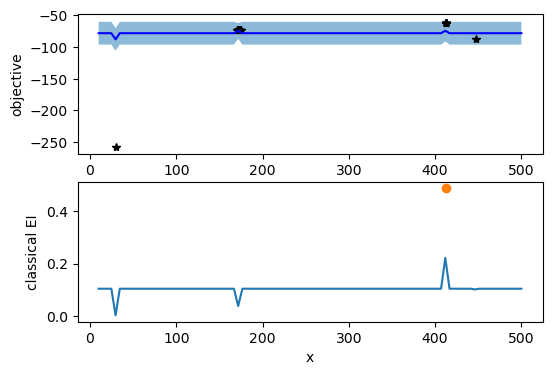

Time elapsed (hh:mm:ss.ms):  0:00:03.840206 

Seed 7: Best obj -13.5692138671875 from interation # 3 at x of 364.4979371371612


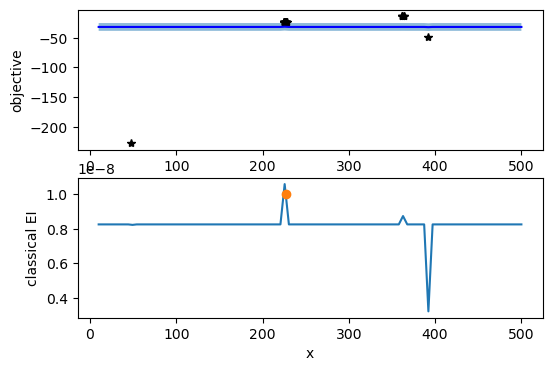

Time elapsed (hh:mm:ss.ms):  0:00:03.732740 

Seed 8: Best obj -7.596424102783203 from interation # 3 at x of 270.1192888622435


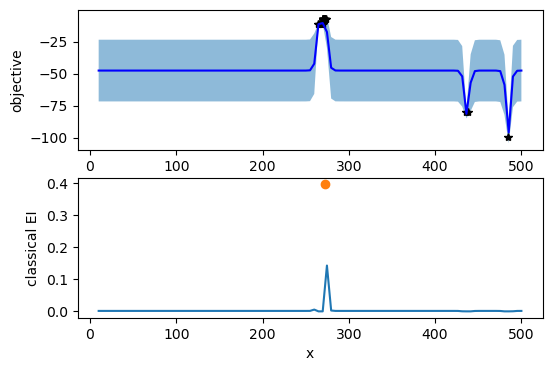

Time elapsed (hh:mm:ss.ms):  0:00:05.836977 

Seed 9: Best obj -17.316757202148438 from interation # 1 at x of 255.91855015288198


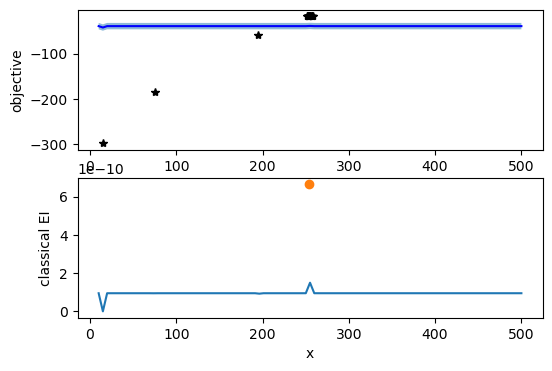

Time elapsed (hh:mm:ss.ms):  0:00:04.196872 

Seed 10: Best obj -0.0 from interation # 2 at x of 320.48763511387494


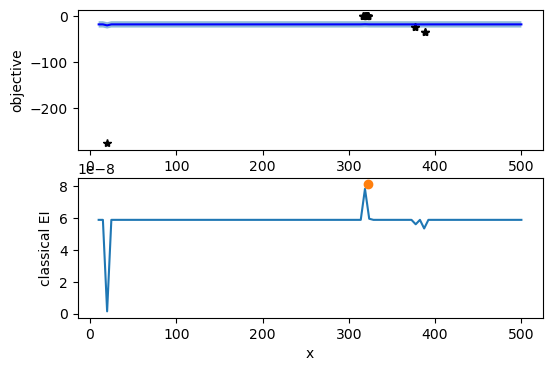

Time elapsed (hh:mm:ss.ms):  0:00:03.706625 

Seed 11: Best obj -13.5692138671875 from interation # 3 at x of 365.2176253041524


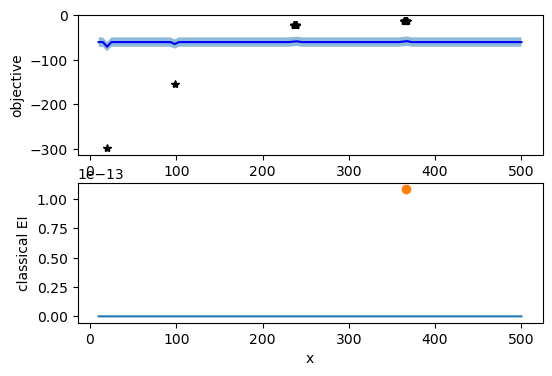

Time elapsed (hh:mm:ss.ms):  0:00:03.913108 

Seed 12: Best obj -7.596424102783203 from interation # 3 at x of 271.53230275634587


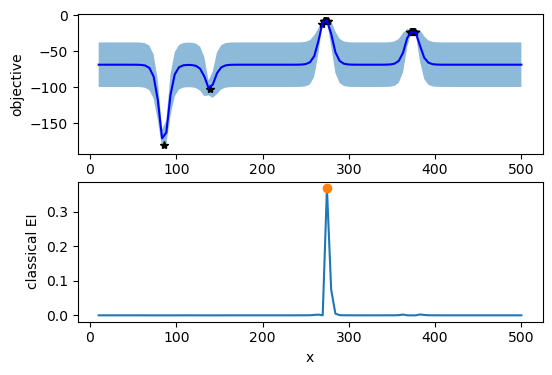

Time elapsed (hh:mm:ss.ms):  0:00:06.606804 

Seed 13: Best obj -35.612648010253906 from interation # 8 at x of 389.2481994628906


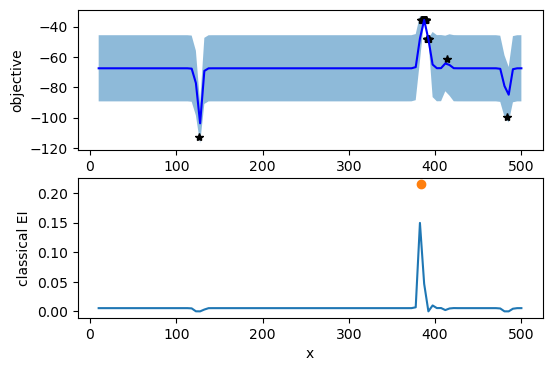

Time elapsed (hh:mm:ss.ms):  0:00:06.257289 

Seed 14: Best obj -11.600391387939453 from interation # 0 at x of 261.8322384486182


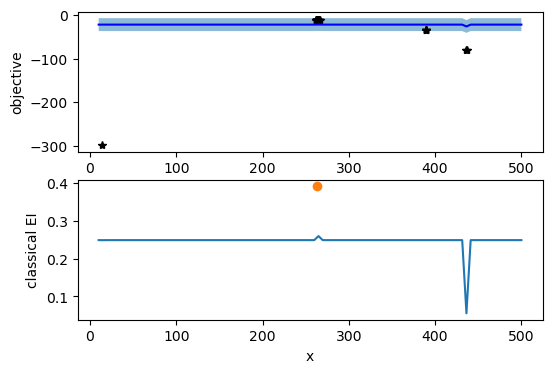

Time elapsed (hh:mm:ss.ms):  0:00:03.925813 

Seed 15: Best obj -67.50370788574219 from interation # 3 at x of 187.15383858322923


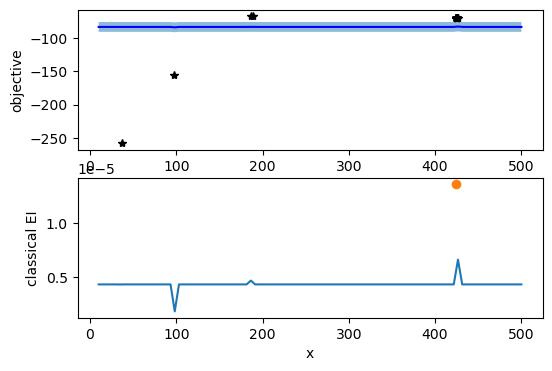

Time elapsed (hh:mm:ss.ms):  0:00:04.011250 

Seed 16: Best obj -4.797336578369141 from interation # 8 at x of 280.12286376953125


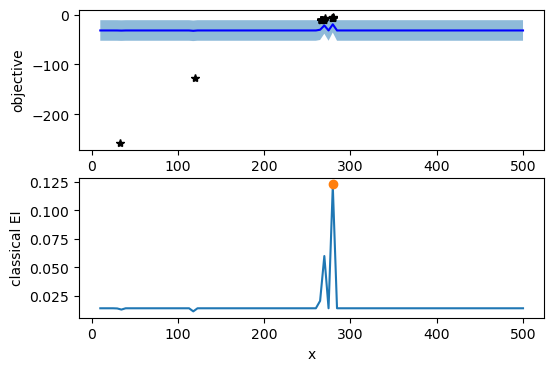

Time elapsed (hh:mm:ss.ms):  0:00:03.996687 

Seed 17: Best obj -7.596424102783203 from interation # 17 at x of 270.1793212890625


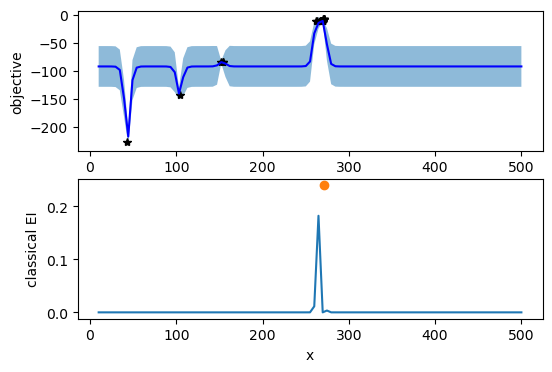

Time elapsed (hh:mm:ss.ms):  0:00:04.451715 

Seed 18: Best obj -0.0 from interation # 0 at x of 328.68337845239995


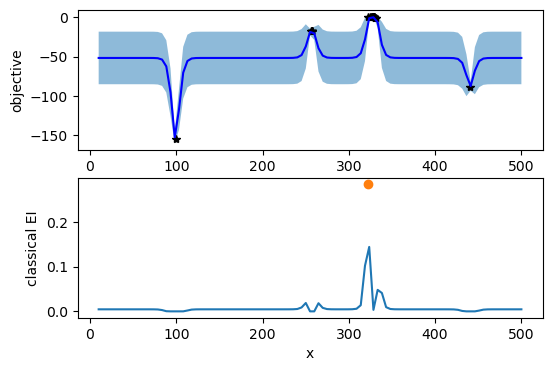

Time elapsed (hh:mm:ss.ms):  0:00:05.555157 

Seed 19: Best obj -23.094207763671875 from interation # 15 at x of 379.58837890625


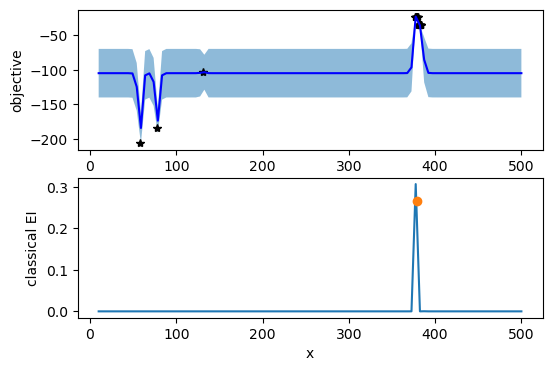

Time elapsed (hh:mm:ss.ms):  0:00:03.943438 

Seed 20: Best obj -0.5697631239891052 from interation # 20 at x of 310.9641418457031


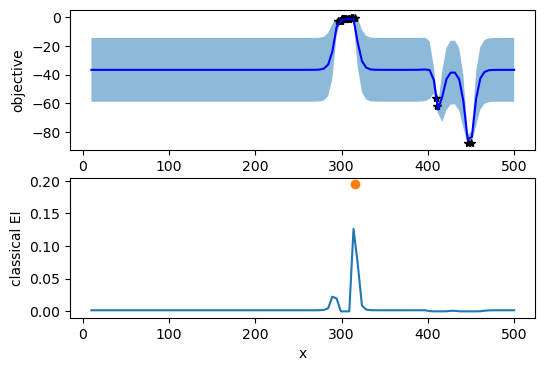

Time elapsed (hh:mm:ss.ms):  0:00:05.999932 

Seed 21: Best obj -4.797336578369141 from interation # 8 at x of 284.7142333984375


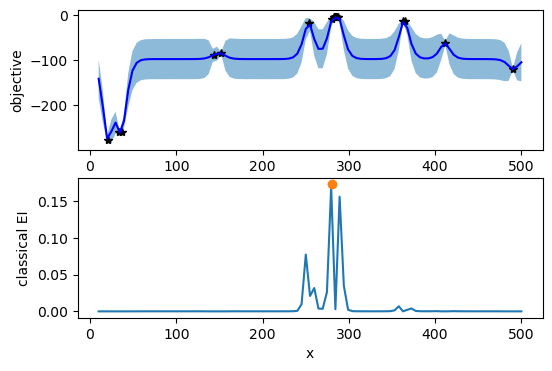

Time elapsed (hh:mm:ss.ms):  0:00:08.250095 

Seed 22: Best obj -17.316757202148438 from interation # 14 at x of 250.21458435058594


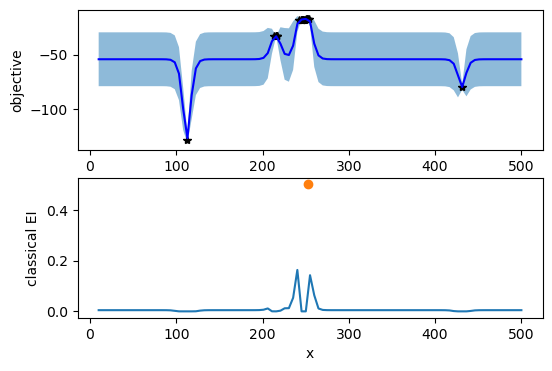

Time elapsed (hh:mm:ss.ms):  0:00:07.297442 

Seed 23: Best obj -7.596424102783203 from interation # 18 at x of 270.1643371582031


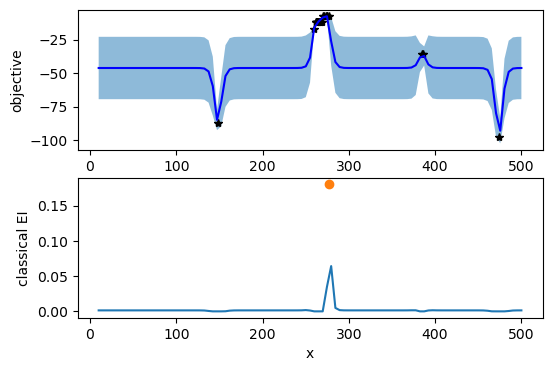

Time elapsed (hh:mm:ss.ms):  0:00:06.807117 

Seed 24: Best obj -2.619086742401123 from interation # 21 at x of 348.656005859375


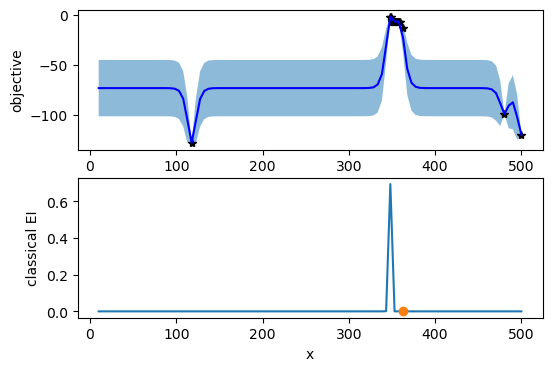

Time elapsed (hh:mm:ss.ms):  0:00:04.342282 

Seed 25: Best obj -1.6265268325805664 from interation # 15 at x of 300.841796875


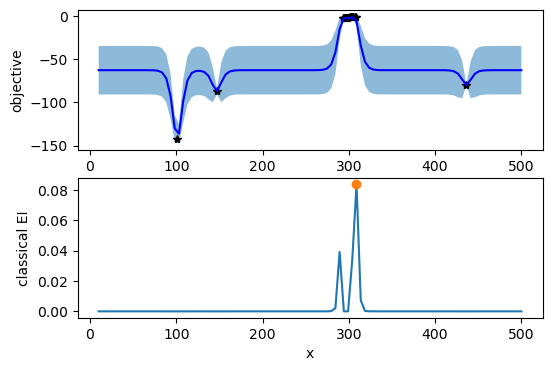

Time elapsed (hh:mm:ss.ms):  0:00:04.644047 

Seed 26: Best obj -7.596424102783203 from interation # 14 at x of 270.2078552246094


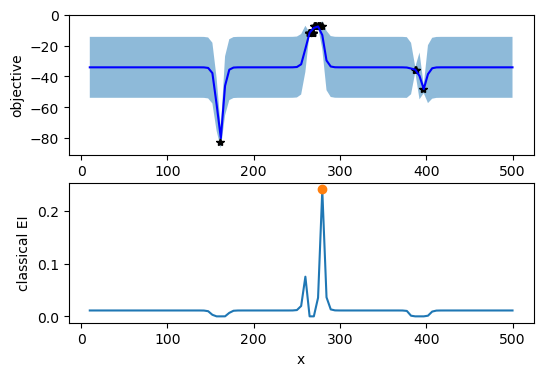

Time elapsed (hh:mm:ss.ms):  0:00:05.468415 

Seed 27: Best obj -13.5692138671875 from interation # 11 at x of 369.2366027832031


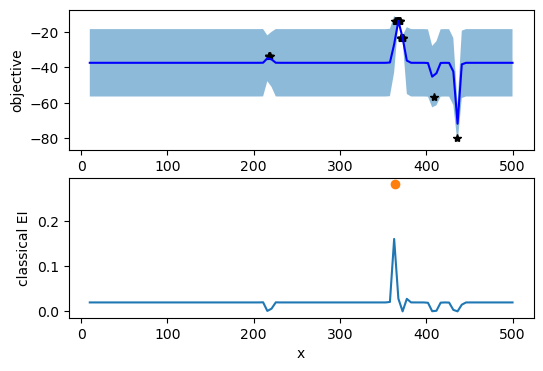

Time elapsed (hh:mm:ss.ms):  0:00:05.664973 

Seed 28: Best obj -4.797336578369141 from interation # 1 at x of 285.00740514054417


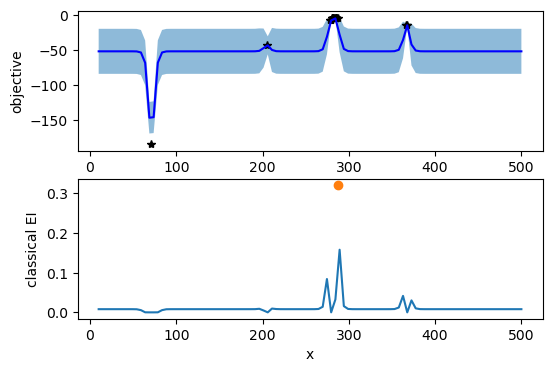

Time elapsed (hh:mm:ss.ms):  0:00:04.548423 

Seed 29: Best obj -23.094207763671875 from interation # 22 at x of 379.4693908691406


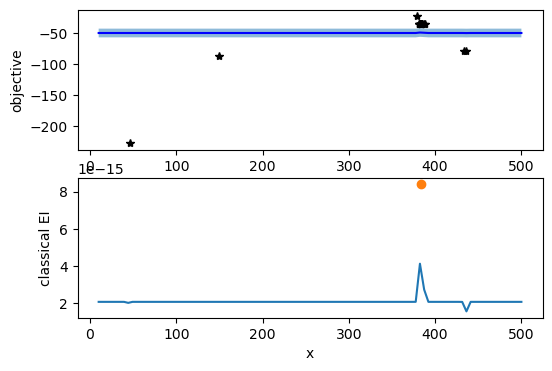

Time elapsed (hh:mm:ss.ms):  0:00:03.757876 



In [106]:
bestArr = []
xArr = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for seed in range(30):
        start = datetime.now()
    
        np.random.seed(seed)
        torch.manual_seed(seed)
        random.seed(seed)
        
        n_initial_points = 4
        n_BO_points = 20
        
        # Generate initial data: several datapoints at random
        # Each one of them will be uniform between 0 and 3
        for i in range(n_initial_points):    
            new_x = torch.tensor(lower + np.random.rand(1)*(upper-lower)).unsqueeze(0) # This is a vector containing 1 entry
            if i == 0:
                x,y,obj = add_data(new_x)
            else:
                x,y,obj = add_data(new_x,x,y,obj)
        
        #print(x.shape, y.shape, obj.shape)
                
        best = [obj.max().detach().item()] #[obj.min()] # Store the index of the best value
        best_x_idx = obj.argmax()
        #print('Best value found: {}'.format(best[-1]))
        
        for i in range(n_BO_points):
            # Fit the model
            # noise = torch.ones_like(obj) * 0.0001
            # model = FixedNoiseGP(x, obj, noise)
            #question 1203: single task GP vs. fixed noise GP
            model = SingleTaskGP(x, obj)
            fit_gpytorch_model(ExactMarginalLogLikelihood(model.likelihood, model))
        
            #print(model.train_targets.shape)
            mll = ExactMarginalLogLikelihood(model.likelihood, model)
            mll(model(x), obj.squeeze(1)).item()
            
            # Optimize EI, considering the problem to be a minimization problem
            EI = ExpectedImprovement(model=model, best_f=obj.max())
            new_point, new_point_EI = optimize_acqf( #error: "_sobol_engine_draw" not implemented for 'Long'
                acq_function=EI,
                bounds=torch.tensor([[lower], [upper]]).float(),#, #bounds is longtensor wihtout float()
                q=1,
                num_restarts=50,
                raw_samples=100,
            )
            
            # # Plot the posterior and the EI
            # f, (ax1,ax2) = plt.subplots(2, 1, figsize=(6, 4))
            # test_x = torch.linspace(lower, upper, 101)
            
            # # Plot the posterior
            # plot_posterior_classic(ax1,model,test_x,x,obj,legend=False)
            
            # # Plot EI
            # acq = EI.forward(test_x.unsqueeze(1).unsqueeze(1))
            # ax2.plot(test_x.numpy(), acq.detach().numpy(), '-', new_point.numpy(), new_point_EI.numpy(),'o')
            # ax2.set_ylabel('classical EI')
            # ax2.set_xlabel('x')
            
            #print('Iteration {}, measuring at x={}'.format(i,new_point.item()) )
            #plt.show()
            
            x,y,obj = add_data(new_point,x,y,obj) #new_point: [1,1] tensor
            best.append(obj.max().item()) #obj.min())
            best_x_idx=obj.argmax()
            #print('Best obj found so far: {} from interation # {} at x of {}'.format(obj.max(),best_x_idx,x[best_x_idx].item()))
        
        print('Seed {}: Best obj {} from interation # {} at x of {}'.format(seed,
                                                                            obj.max(),
                                                                            best_x_idx,
                                                                            x[best_x_idx].item()))
        # Plot the posterior and the EI
        f, (ax1,ax2) = plt.subplots(2, 1, figsize=(6, 4))
        test_x = torch.linspace(lower, upper, 101)
        
        # Plot the posterior
        plot_posterior_classic(ax1,model,test_x,x,obj,legend=False)
        
        # Plot EI
        acq = EI.forward(test_x.unsqueeze(1).unsqueeze(1))
        ax2.plot(test_x.numpy(), acq.detach().numpy(), '-', new_point.numpy(), new_point_EI.numpy(),'o')
        ax2.set_ylabel('classical EI')
        ax2.set_xlabel('x')
        plt.show()
    
        torch.cuda.synchronize()
        end = datetime.now()
        print('Time elapsed (hh:mm:ss.ms):  {} \n'.format(end-start))
    
        bestArr.append(best)
        xArr.append(x.squeeze().numpy())

In [107]:
bestArr = np.array(bestArr)
xArr = np.array(xArr)
np.savez('20241202-classical_initial4.npz',bestArr=bestArr,xArr = xArr)

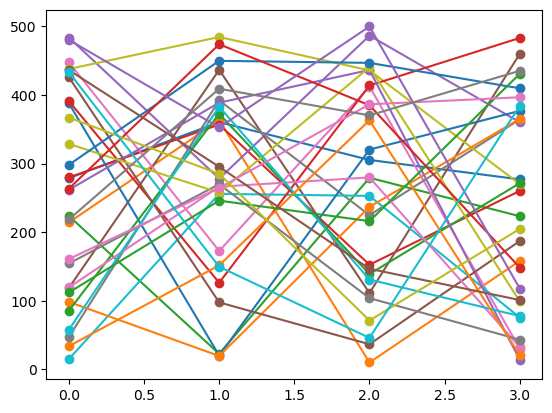

In [112]:
plt.figure()
plt.plot(xArr[:,:4].T,'o-');

In [113]:
xArr[2,:4]

array([223.63750205,  22.7038536 , 279.33461416, 223.30797238])

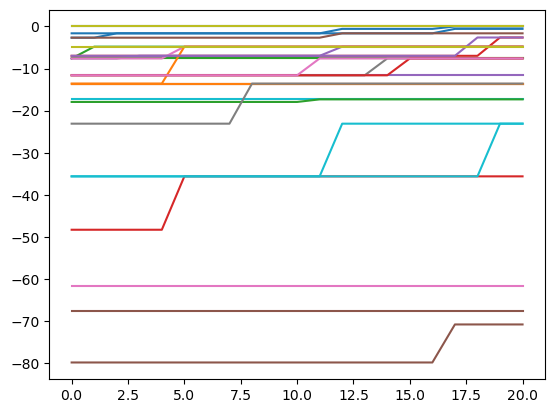

In [109]:
plt.figure()
plt.plot(bestArr.T);

In [114]:
bestAvg = np.mean(bestArr,axis=0)
bestStd = np.std(bestArr,axis=0)

Text(0, 0.5, 'Objective')

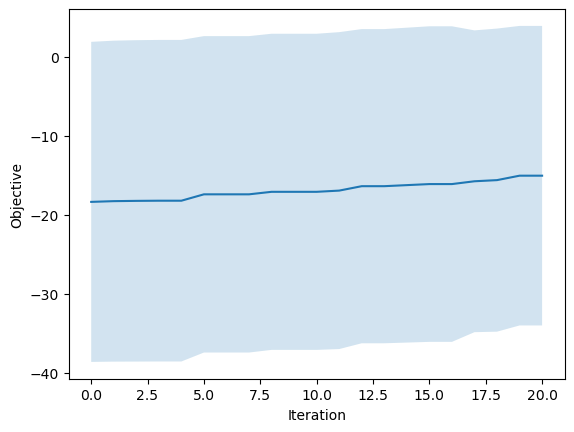

In [121]:
plt.figure()
plt.plot(bestAvg)
plt.fill_between(range(len(bestAvg)),bestAvg-bestStd,bestAvg+bestStd,alpha=0.2)
plt.xlabel('Iteration')
plt.ylabel('Objective')

## TODO: performance for x(thickness, ***tilt***)